## 1. Data preprocessing

In [1]:
import pandas as pd

data_path = "../data/GermanCredit/"
df = pd.read_csv(data_path + "german_credit_data.csv", index_col=0)
df.reset_index(drop=True, inplace=True)


In [2]:
# # NOTEARS and ReX require numeric, complete matrices, so missing data must be resolved.
# df = df.fillna(df.median())

print(df.shape)
df = df.dropna()
df.head()

print(df.shape)

(1000, 10)
(522, 10)


In [3]:
# Only supports numeric input. Categorical features must be encoded numerically.
df.dtypes

Age                 int64
Sex                object
Job                 int64
Housing            object
SavingAccounts     object
CheckingAccount    object
CreditAmount        int64
Duration            int64
Purpose            object
LoanOutcome        object
dtype: object

In [4]:
pd.value_counts(df['LoanOutcome'])

/var/folders/4x/nynq10qj2kz8_zbvh7mnk0y00000gn/T/ipykernel_20926/1819783371.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['LoanOutcome'])


LoanOutcome
good    291
bad     231
Name: count, dtype: int64

In [5]:
df.describe()

,Age,Job,CreditAmount,Duration
count,522.000000,522.000000,522.000000,522.000000
mean,34.888889,1.875479,3278.745211,21.339080
std,11.787918,0.682811,2929.155177,12.474079
min,19.000000,0.000000,276.000000,6.000000
25%,26.000000,2.000000,1297.500000,12.000000
50%,31.500000,2.000000,2326.500000,18.000000
75%,41.000000,2.000000,3971.250000,26.750000
max,75.000000,3.000000,18424.000000,72.000000


In [6]:
# # Continuous numeric features should be scaled. Recommended for NOTEARS (sensitive to magnitude)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df_scaled = pd.DataFrame(
#     scaler.fit_transform(df),
#     columns=df.columns
# )

# df_scaled.head()

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


class GermanCreditDataPreprocessor:
    """
    Preprocessing pipeline for GermanCredit dataset
    Causal discovery–ready (ReX / NOTEARS / PC / GES)
    """

    def __init__(
        self,
        path,
        test_size=0.2,
        random_state=42,
        subsample_ratio=1.0,  # 1.0 = balanced, None = full dataset
    ):
        self.path = path
        self.test_size = test_size
        self.random_state = random_state
        self.subsample_ratio = subsample_ratio

        self.target = "LoanOutcome"

        # --------------------
        # Variable definitions
        # --------------------

        # Context (protected / non-actionable)
        self.context_vars = ["Sex", "Age"]

        # NOTE: add context variables ["Age"] as numeric_vars
        # Actionable numeric variables
        self.numeric_vars = [
            "CreditAmount",
            "Duration",
            "Age"
        ]

        # NOTE: add context variables ["Sex"] as categorical_vars
        # Actionable categorical variables
        self.categorical_vars = [
            "CheckingAccount",
            "Job",
            "Housing",
            "SavingAccounts",
            "Sex", 
        ]
        
        self.immutable_vars = ["Purpose"]

        self.causal_graph_vars = self.numeric_vars + self.categorical_vars

        self._build_pipeline()

    # ------------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------------
    def _build_pipeline(self):
        self.pipeline = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler()),
                        ]
                    ),
                    self.numeric_vars,
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="most_frequent")),
                            (
                                "encode",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value", unknown_value=-1
                                ),
                            ),
                        ]
                    ),
                    self.categorical_vars,
                ),
            ],
            remainder="drop",
        )

    # ------------------------------------------------------------------
    # Main API
    # ------------------------------------------------------------------
    def load_and_process(self):
        df = pd.read_csv(self.path + "german_credit_data.csv")

        # --------------------
        # Drop missing
        # --------------------
        df = df.dropna().reset_index(drop=True)

        # --------------------
        # Target
        # --------------------
        # Binary encode target
        clss_lbls = ["bad", "good"]
        y = (df["LoanOutcome"] == "good").astype(int).values
        # y = df[self.target].astype(int).values

        # # --------------------
        # # Context encoding
        # # --------------------
        # context = df[self.context_vars].copy().astype(int)

        # --------------------
        # Features for causal discovery
        # --------------------
        X = df[self.causal_graph_vars].copy()

        # --------------------
        # Optional subsampling to balance classes
        # --------------------
        if self.subsample_ratio is not None:
            rng = np.random.default_rng(self.random_state)

            idx_pos = np.where(y == 1)[0]
            idx_neg = np.where(y == 0)[0]
            
            # print(len(idx_pos), len(idx_neg))
            if len(idx_pos) < len(idx_neg):
                idx_neg_sub = np.random.choice(idx_neg, len(idx_pos), replace=False)
                idx_sub = np.hstack([idx_pos, idx_neg_sub])
            elif len(idx_pos) > len(idx_neg):
                idx_pos_sub = np.random.choice(idx_pos, len(idx_neg), replace=False)
                idx_sub = np.hstack([idx_pos_sub, idx_neg])
            else:
                print(f"len(idx_pos) = len(idx_neg) = {len(idx_pos)}")

            # idx_sub = np.concatenate([idx_pos_sub, idx_neg])
            idx_sub = rng.permutation(idx_sub)

            X = X.iloc[idx_sub].reset_index(drop=True)
            y = y[idx_sub]
            # context = context.iloc[idx_sub].reset_index(drop=True)

        # --------------------
        # Train / test split
        # --------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            # context,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        # --------------------
        # Fit + transform
        # --------------------
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)

        self.feature_names_ = self.causal_graph_vars

        # --------------------
        # Report
        # --------------------
        print("\n" + "-" * 80)
        print("Law dataset summary")
        print(f"Samples: {len(y)}")
        print(f"Pass: {y.sum()} | Fail: {(1 - y).sum()}")
        # print(f"male=1: {context['Age'].sum()}")
        # print(f"race=1: {context['Sex'].sum()}")
        print("-" * 80 + "\n")

        return {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            # "context_train": c_train.values,
            # "context_test": c_test.values,
            "feature_names": self.feature_names_,
        }


In [8]:
data = GermanCreditDataPreprocessor(data_path)
data_processed = data.load_and_process()

print("X_train shape:", data_processed["X_train"].shape)
print("feature_names:", data.feature_names_)
print("Positive class rate:", data_processed["y_train"].mean())


--------------------------------------------------------------------------------
Law dataset summary
Samples: 462
Pass: 231 | Fail: 231
--------------------------------------------------------------------------------

X_train shape: (369, 8)
feature_names: ['CreditAmount', 'Duration', 'Age', 'CheckingAccount', 'Job', 'Housing', 'SavingAccounts', 'Sex']
Positive class rate: 0.5013550135501355


In [9]:
train_processed = pd.DataFrame(data_processed['X_train'], columns=data_processed['feature_names'])

train_processed.to_csv("./data_processed/germancredit_processed_downsampled.csv", index=False)

In [10]:
train_processed

,CreditAmount,Duration,Age,CheckingAccount,Job,Housing,SavingAccounts,Sex
0,-0.344962,1.163142,-0.929779,1.0,2.0,2.0,0.0,1.0
1,-0.657212,-1.001293,-0.673041,0.0,3.0,0.0,0.0,1.0
2,-0.733802,0.201171,-0.758620,1.0,2.0,1.0,0.0,1.0
3,0.186660,0.682157,0.439494,0.0,3.0,1.0,0.0,1.0
4,-0.497795,-0.279815,-0.844200,0.0,2.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...
364,-0.240301,-0.440143,0.696233,0.0,2.0,2.0,0.0,1.0
365,4.281261,2.125113,-1.015359,1.0,2.0,1.0,0.0,1.0
366,1.192029,2.125113,-0.330722,0.0,2.0,1.0,0.0,0.0
367,0.635455,0.201171,-0.844200,2.0,2.0,1.0,0.0,1.0


## 2. Causal discovery models

In [11]:
from causalexplain import GraphDiscovery

# Create experiment object
gd = GraphDiscovery(
    experiment_name="germancredit_causal",
    model_type="rex",               
    csv_filename="./data_processed/germancredit_processed_downsampled.csv", # your dataset
)

### 2.1 With no prior constraints

In [12]:
# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

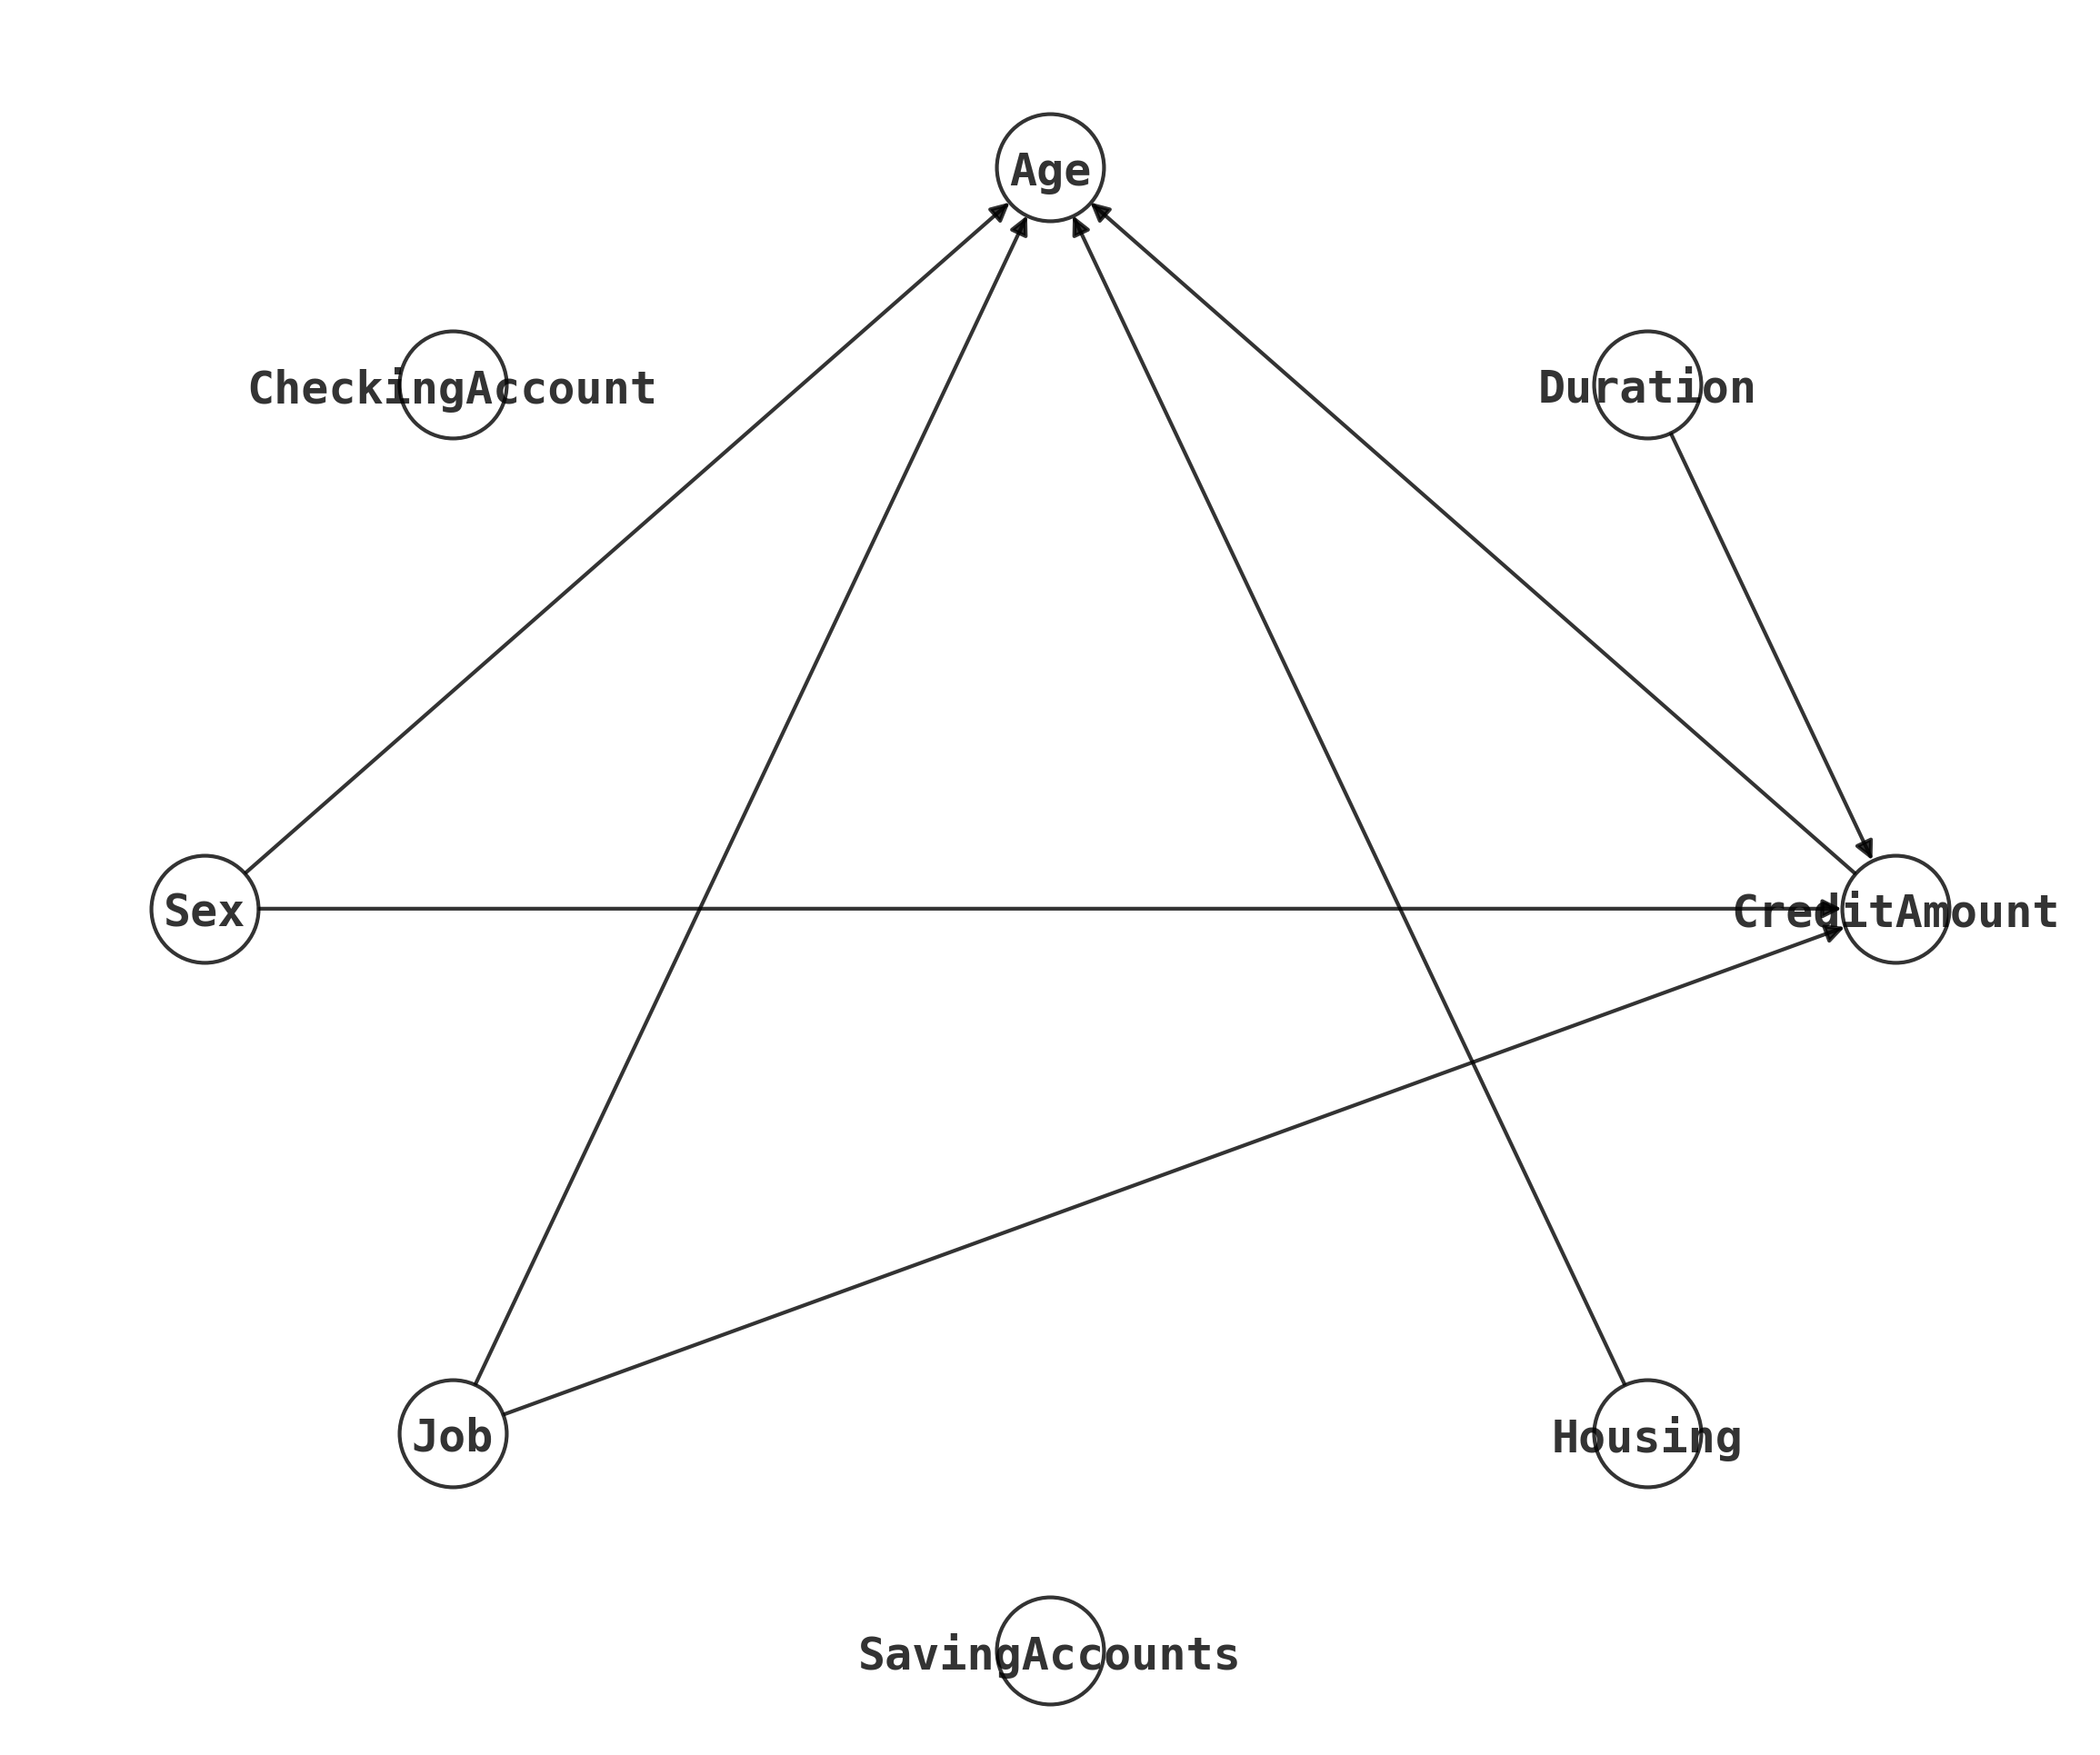

In [13]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [14]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_germancredit/germancredit_rex3_no_constraints.dot") 

### 2.2 With 4-tier prior constraints

In [15]:
prior = [
    ["Sex", "Age"],  # Tier 0: Demographics
    ["Job"],  # Tier 1: Human capital
    [
        "CheckingAccount",
        "SavingAccounts",
        "Housing",
    ],  # Tier 2: Accumulated financial status
    [
        "CreditAmount",
        "Duration",
    ],  # Tier 3: Loan decision
]


In [16]:
# NOTE: run with constraints: prior

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)



Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

In [17]:
# Numbers of trainer from REX
print(gd.trainer)
print()

# SHAP sampling summary
print(gd._sampling_summary())

{'germancredit_processed_downsampled_nn': <causalexplain.common.notebook.Experiment object at 0x34552e1e0>, 'germancredit_processed_downsampled_gbt': <causalexplain.common.notebook.Experiment object at 0x32a7299d0>, 'germancredit_processed_downsampled_rex': <causalexplain.common.notebook.Experiment object at 0x331bc7140>}

SHAP adaptive sampling: no_sampling (K=1, samples=369)


In [18]:
import networkx as nx

print(gd.dag.number_of_nodes())
print(gd.dag.number_of_edges())

8
3


In [19]:
# Adjacency matrix
import pandas as pd

adj_df = pd.DataFrame(
    nx.to_numpy_array(gd.dag, nodelist=gd.data_columns),
    index=gd.data_columns,
    columns=gd.data_columns
)

adj_df

,CreditAmount,Duration,Age,CheckingAccount,Job,Housing,SavingAccounts,Sex
CreditAmount,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Duration,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Age,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CheckingAccount,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Job,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
Housing,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SavingAccounts,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Sex,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


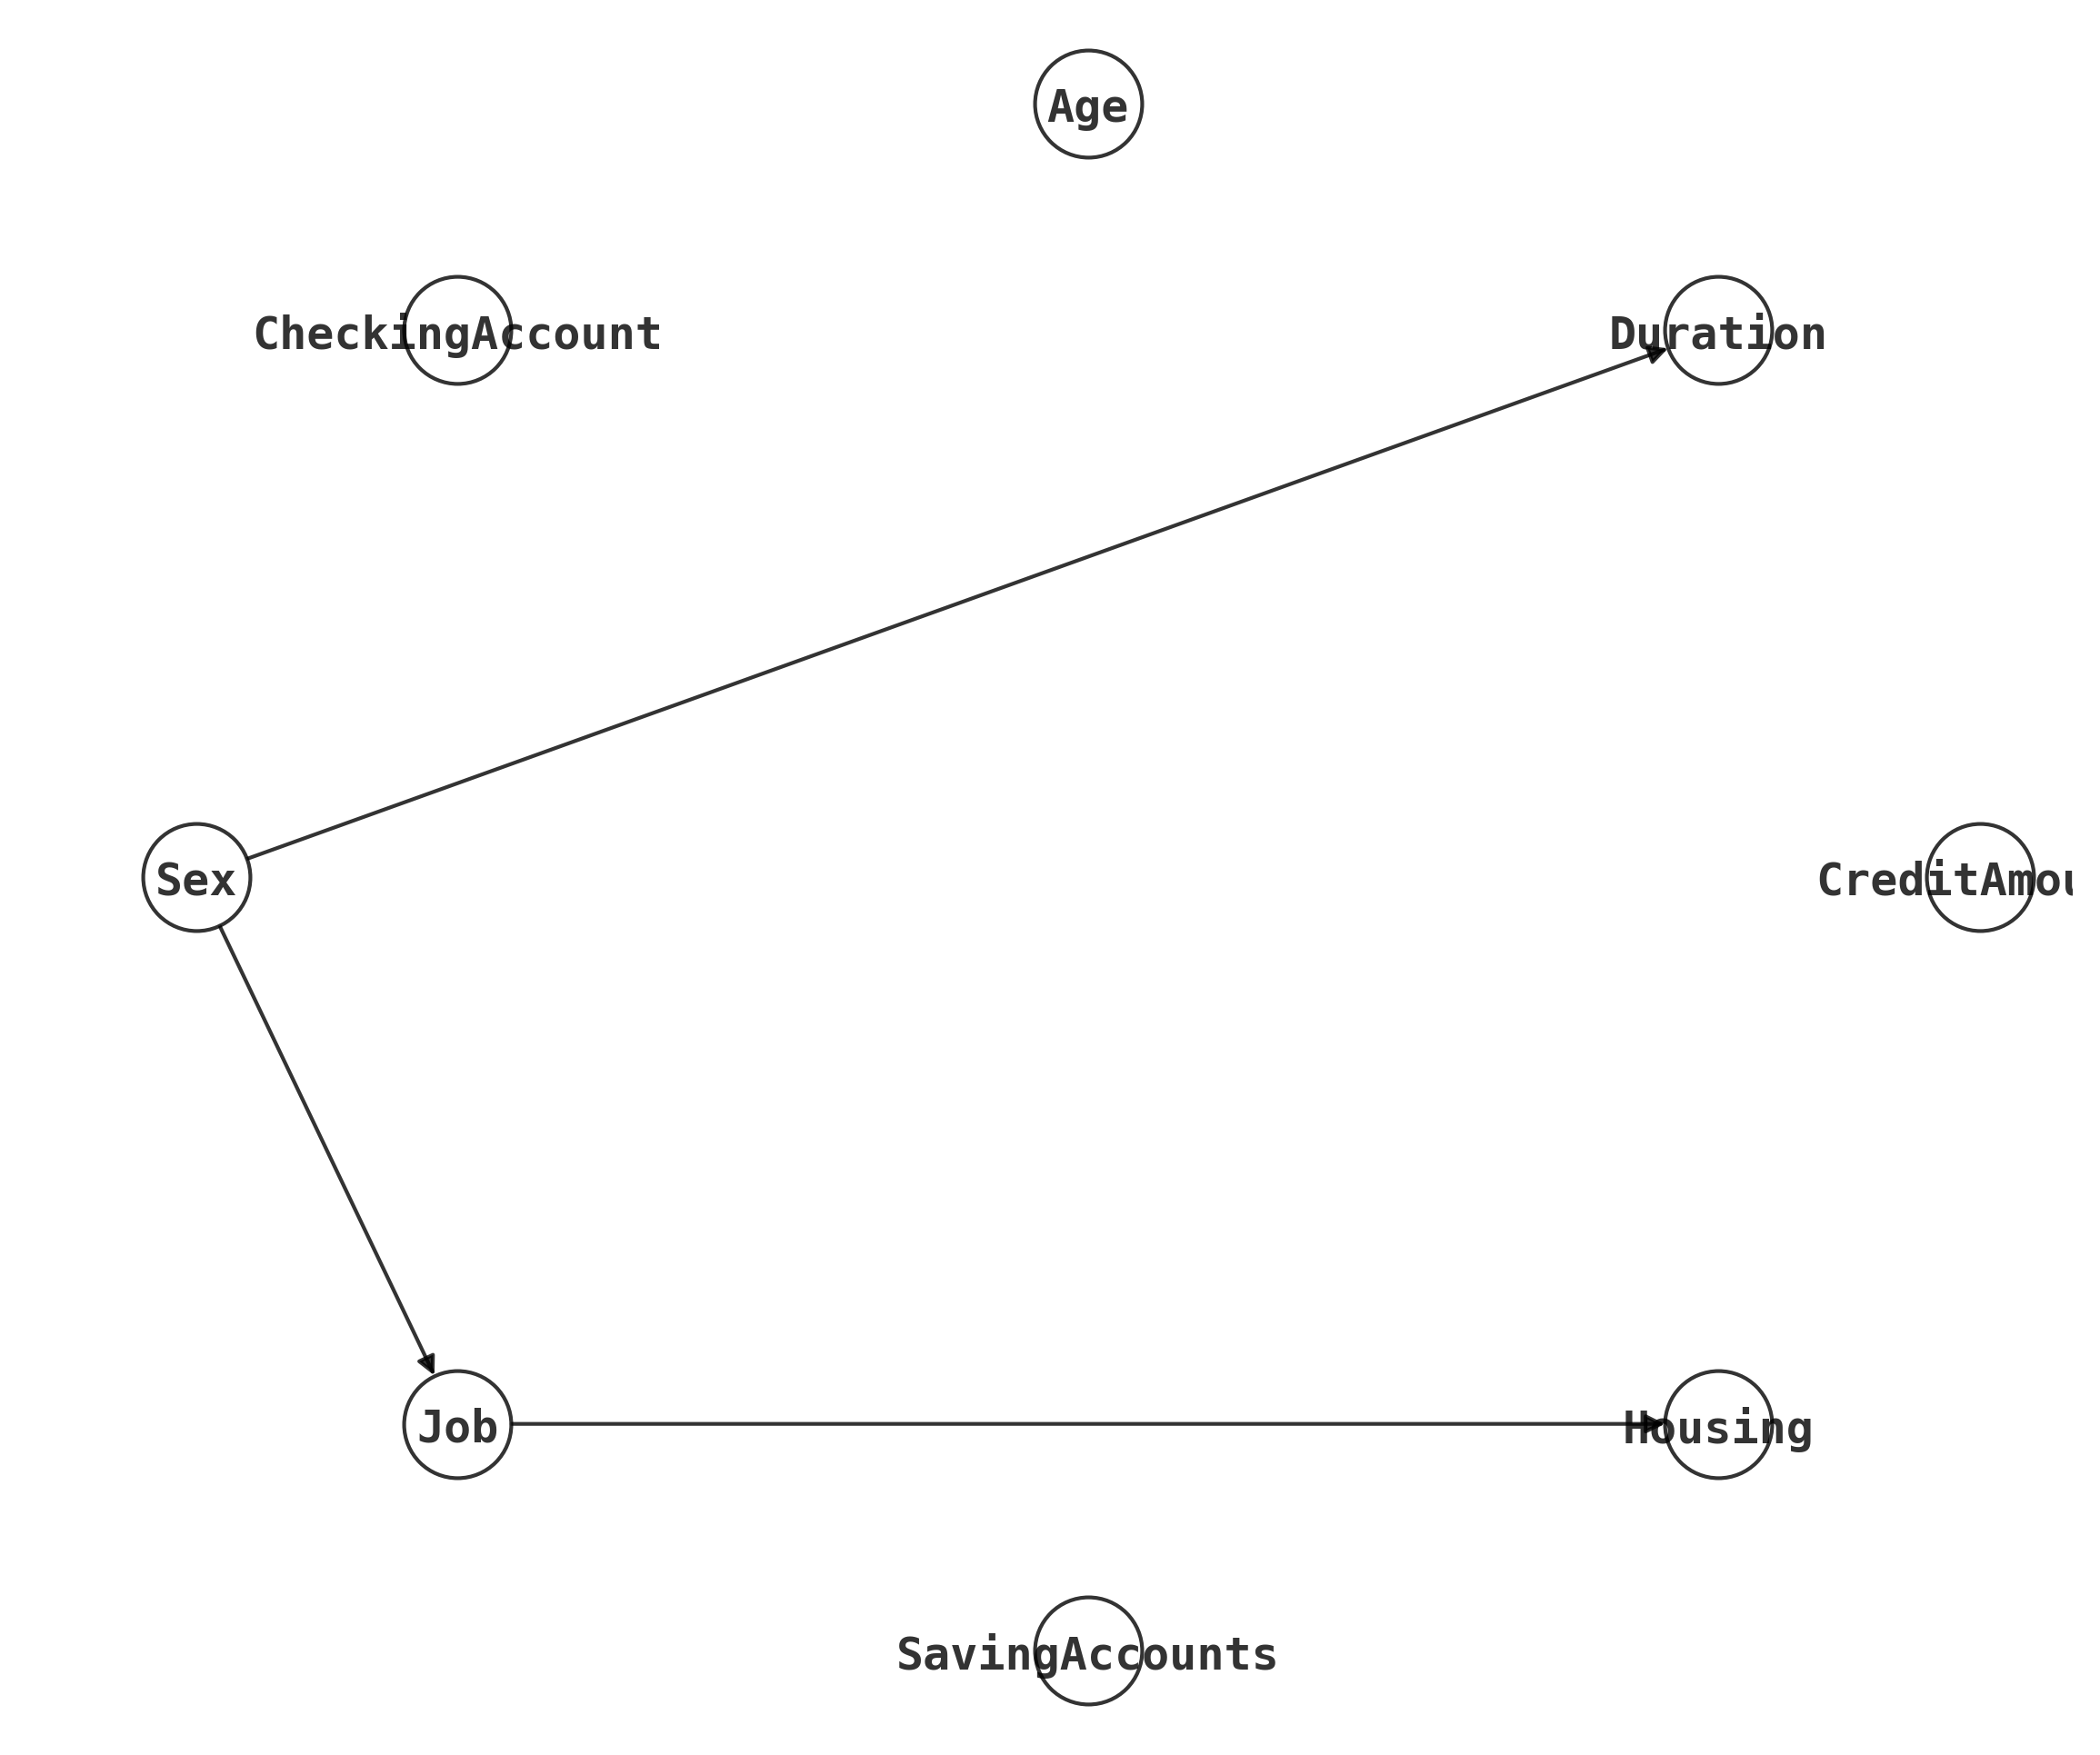

In [20]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [21]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [22]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_germancredit/germancredit_rex4_constraints.dot")

### 2.3 With minimal prior constraints

In [23]:
prior_minimal = [
    ["Sex", "Age"],
    [
        "CheckingAccount",
        "SavingAccounts",
        "Job",
        "Housing",
        "CreditAmount",
        "Duration",
    ],
]

In [24]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_minimal,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

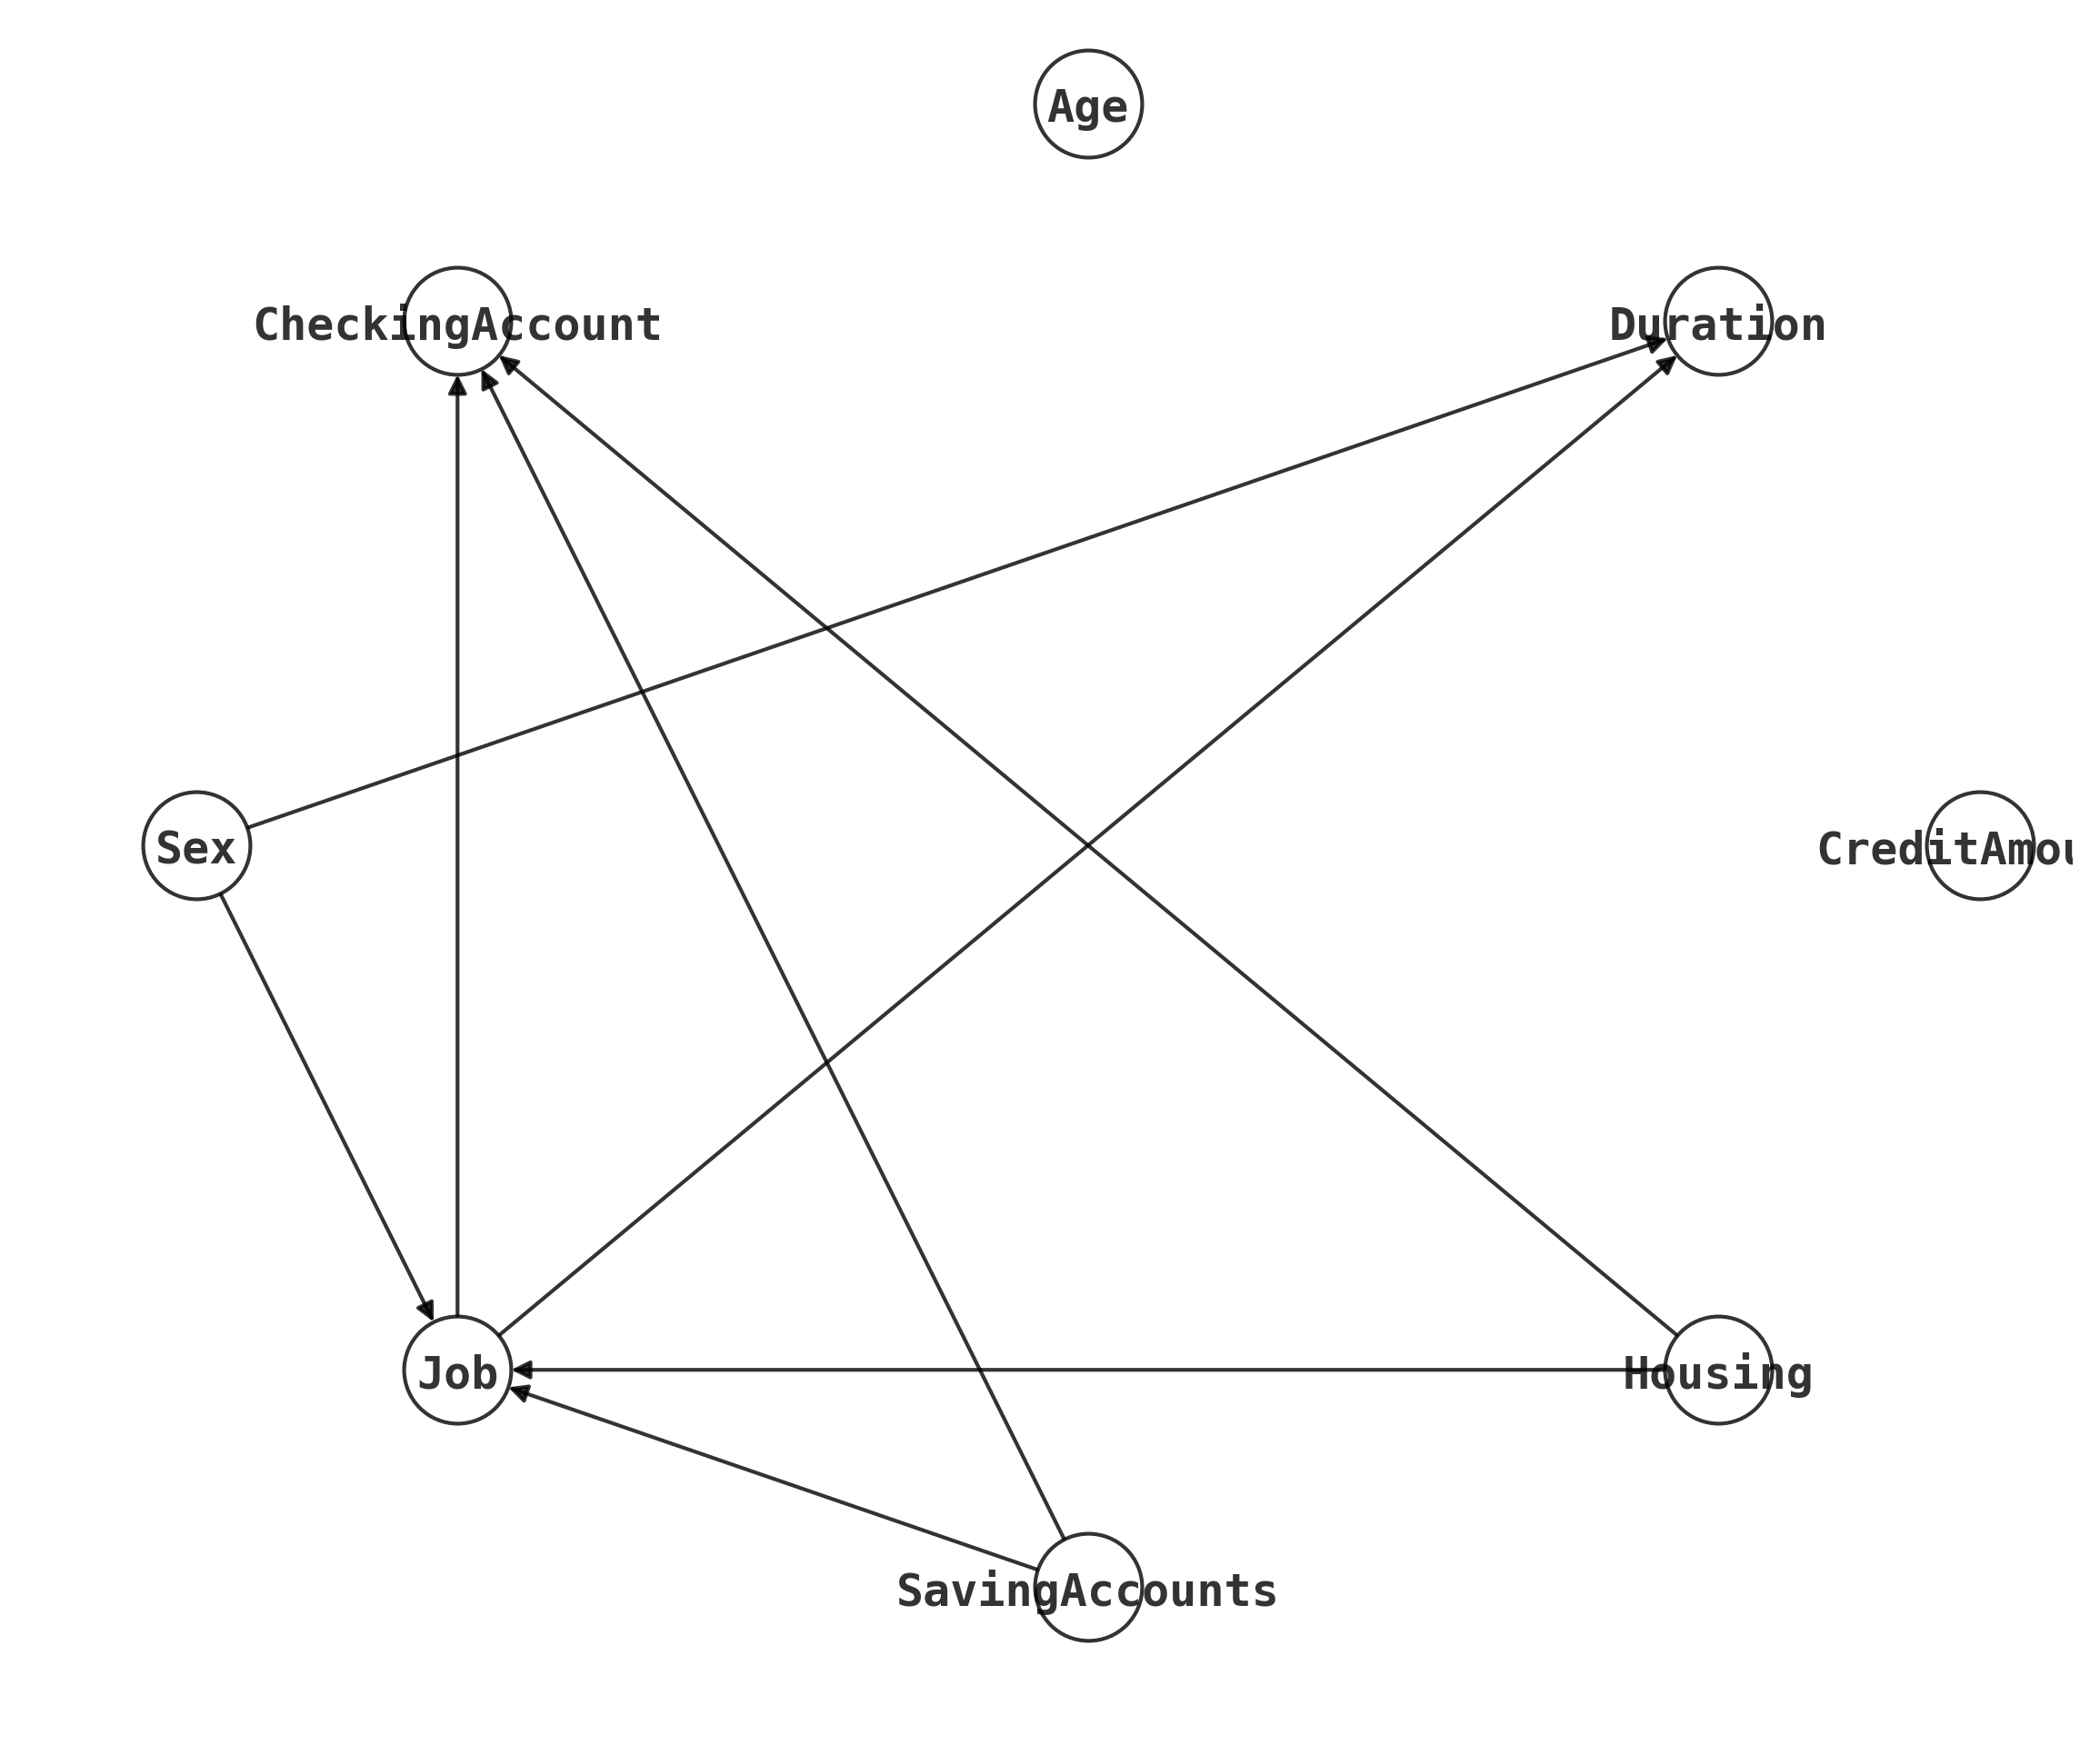

In [25]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [26]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [27]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_germancredit/germancredit_rex5_constraints_min.dot")

### 2.4 With moderate prior constraints

In [28]:
prior_mod = [
    ["Sex", "Age"],  # Tier 0: Demographics
    [
        "CheckingAccount",
        "SavingAccounts",
        "Job",
        "Housing",
    ],  # Tier 1: Financial & employment profile
    [
        "CreditAmount",
        "Duration",
    ],  # Tier 2: Loan contract terms
]

In [29]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_mod,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

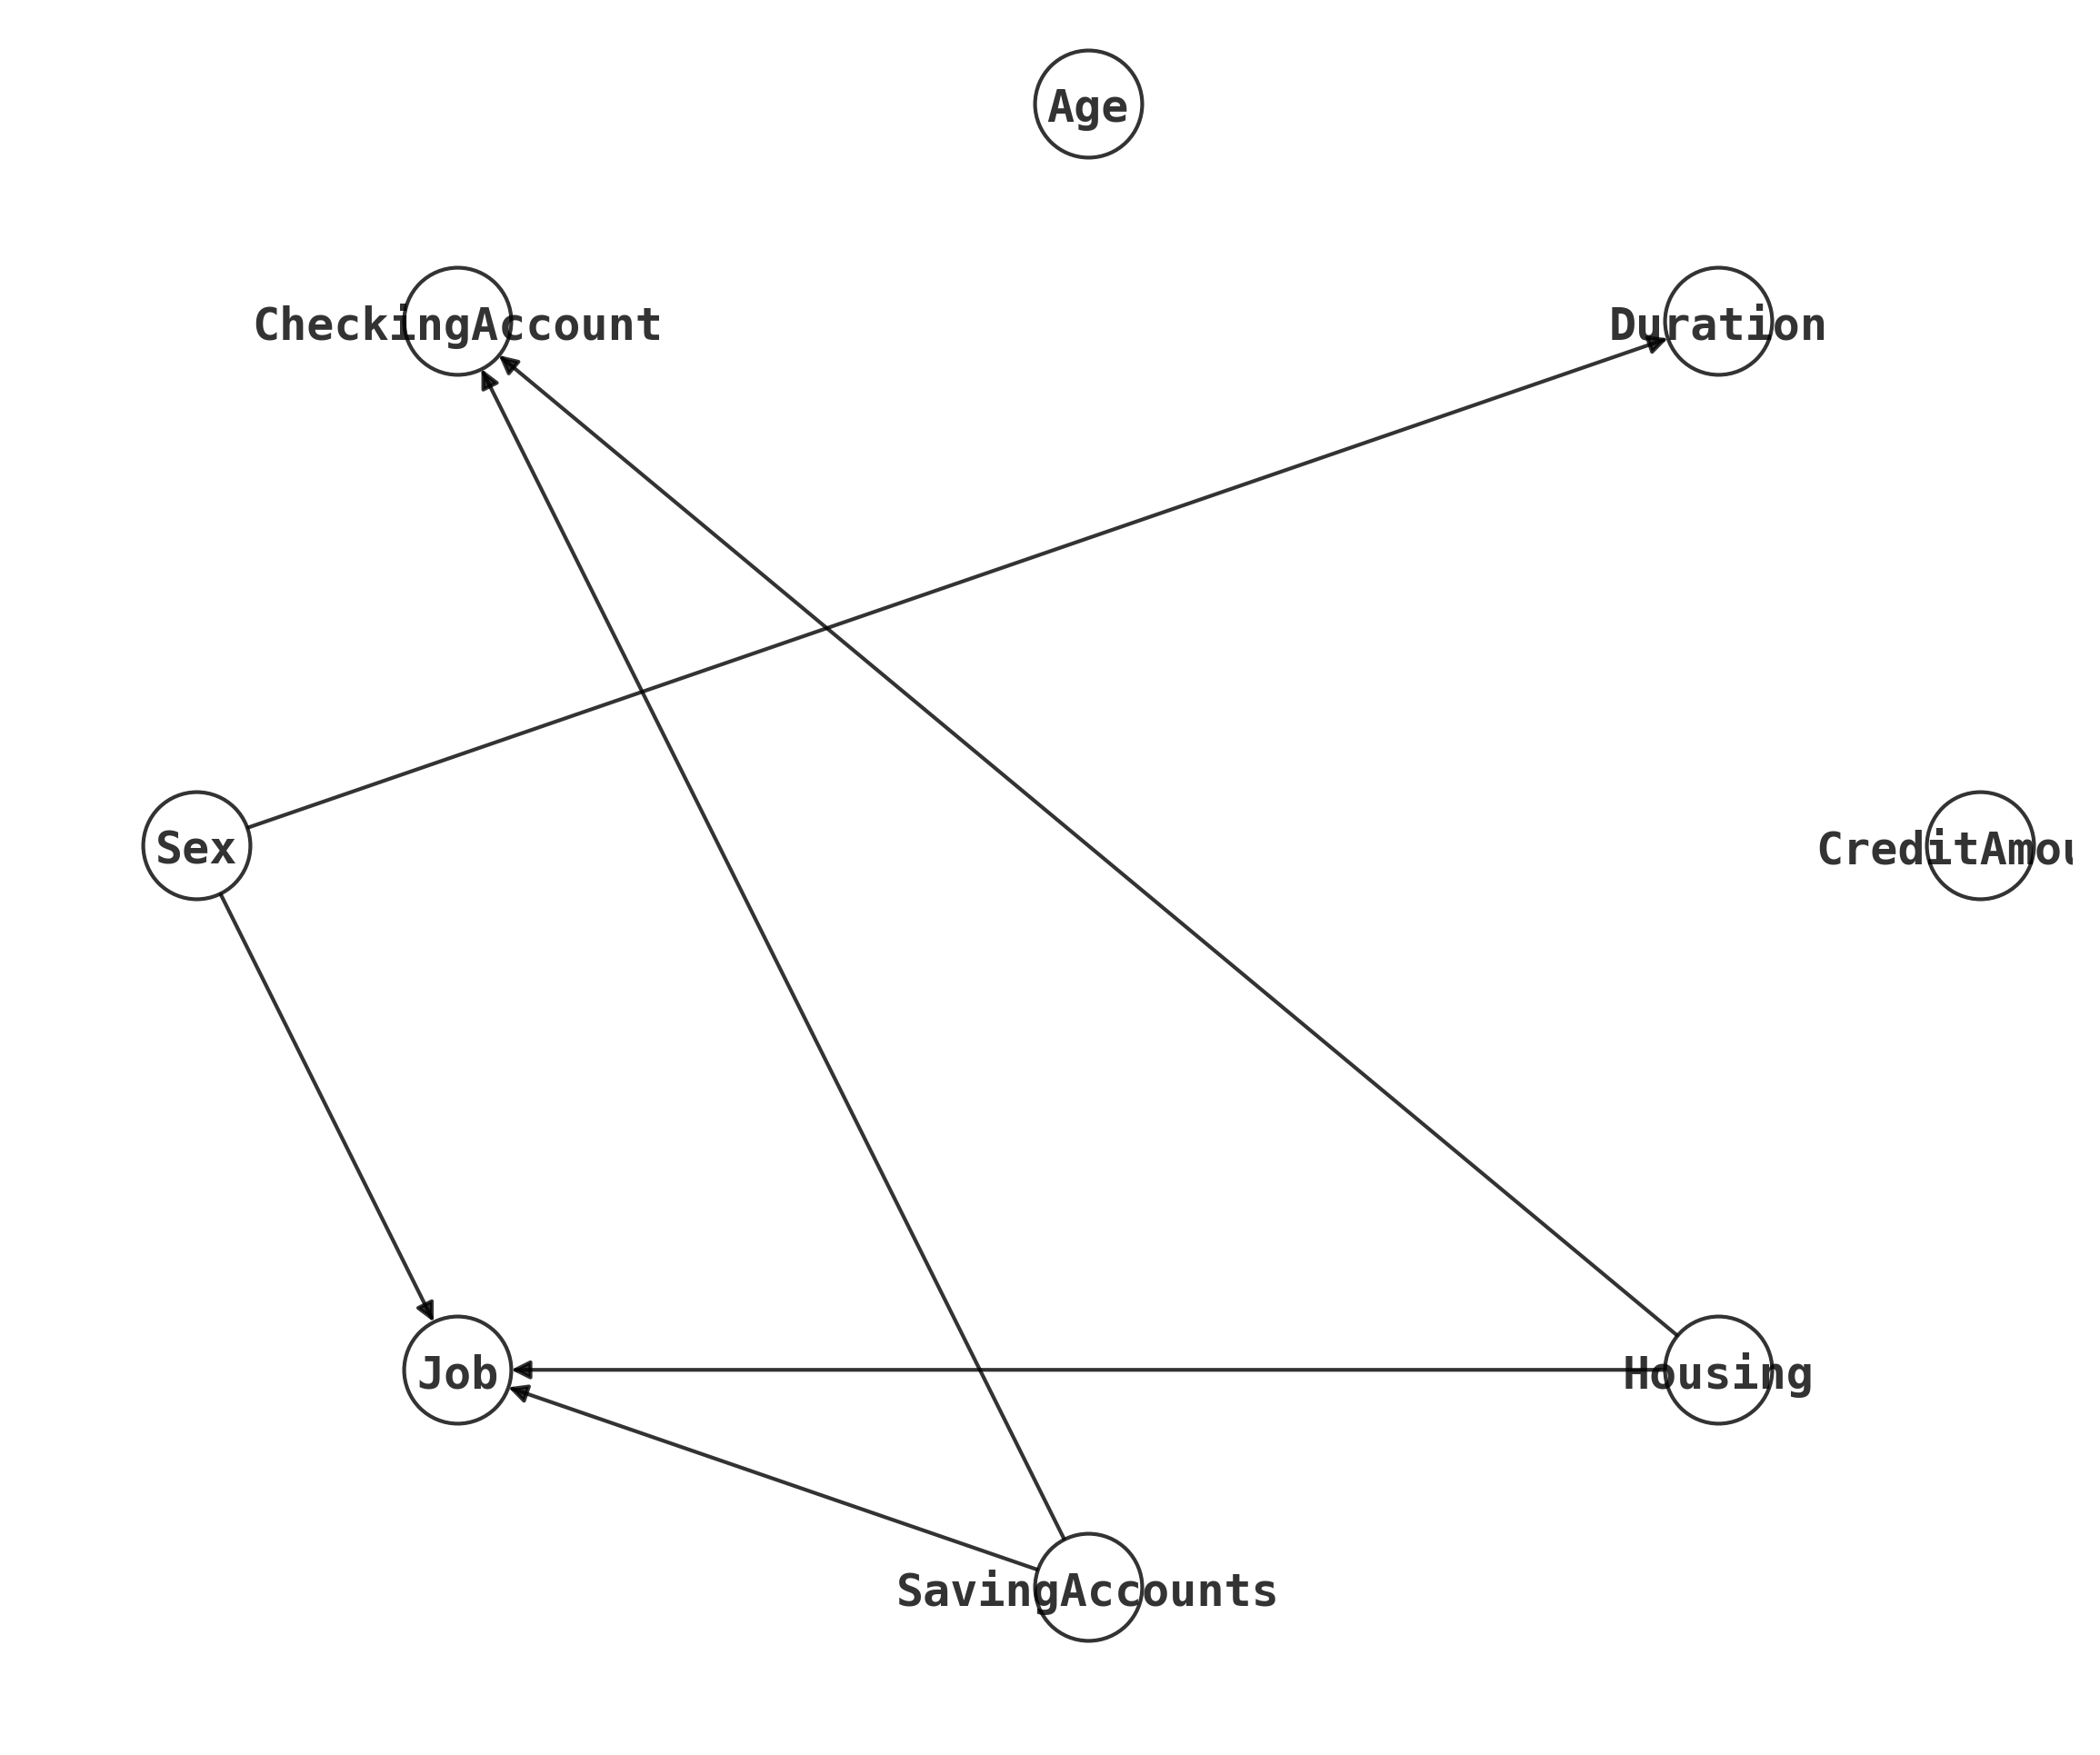

In [30]:
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [31]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_germancredit/germancredit_rex6_constraints_mod.dot")